In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchaudio
import torchaudio.transforms as T
from pathlib import Path
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memory: 4.29 GB


In [2]:
config = {
    'project': {'seed': 42, 'num_workers': 0},
    'paths': {
        'data_root': r'G:\.shortcut-targets-by-id\1ua-L70AEx_VqEEKdgxjSMzr-wEX6GnxK\voice-manipulation-detection',
        'checkpoints': './models/checkpoints/cnn',
        'experiments_root': './experiments/cnn'
    },
    'data': {'debug_mode': False, 'subset_fraction': 0.43, 'max_length': 64000},
    'model': {'hidden_channels': 64, 'dropout': 0.5, 'label_smoothing': 0.1},
    'training': {
        'batch_size': 32,
        'num_epochs': 15,
        'learning_rate': 0.0001,
        'weight_decay': 0.0001,
        'gradient_clip': 1.0,
        'optimizer': {'betas': [0.9, 0.999]},
        'scheduler': {'min_lr': 1e-07},
        'early_stopping': {'enabled': True, 'patience': 5}
    },
    'logging': {'log_interval': 10},
    'reproducibility': {'deterministic': True, 'benchmark': False}
}

print(f"CNN | Batch: {config['training']['batch_size']} | LR: {config['training']['learning_rate']} | Data: {config['data']['subset_fraction']*100:.0f}%")

CNN | Batch: 32 | LR: 0.0001 | Data: 43%


In [3]:
class ASVspoofDataset(Dataset):
    def __init__(self, config, split='train', precomputed_cache_dir='./lfcc_cache'):
        import soundfile as sf
        import librosa
        self.sf = sf
        self.librosa = librosa
        self.config = config
        self.split = split
        self.root_dir = config['paths']['data_root']
        self.cache_dir = Path(precomputed_cache_dir) / split
        self.cache_dir.mkdir(parents=True, exist_ok=True)

        protocol_dir = os.path.join(self.root_dir, 'data', 'raw', 'ASVspoof2019', 'LA', 'LA', 'ASVspoof2019_LA_cm_protocols')
        protocol_files = {'train': 'ASVspoof2019.LA.cm.train.trn.txt', 'dev': 'ASVspoof2019.LA.cm.dev.trl.txt', 'eval': 'ASVspoof2019.LA.cm.eval.trl.txt'}
        protocol_path = os.path.join(protocol_dir, protocol_files[split])

        if not os.path.exists(protocol_path):
            raise FileNotFoundError(f"Protocol file not found: {protocol_path}")

        self.metadata = pd.read_csv(protocol_path, sep=' ', header=None, names=['speaker', 'filename', 'system', 'null', 'label'])

        if config['data'].get('subset_fraction', 1.0) < 1.0:
            self.metadata = self.metadata.sample(frac=config['data']['subset_fraction'], random_state=42).reset_index(drop=True)

        self.audio_dir = os.path.join(self.root_dir, 'data', 'raw', 'ASVspoof2019', 'LA', 'LA', f'ASVspoof2019_LA_{split}', 'flac')
        self.max_length = config['data'].get('max_length', 64000)

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        cache_path = self.cache_dir / f"{row['filename']}.pt"

        if cache_path.exists():
            try:
                data = torch.load(cache_path, weights_only=True)
            except TypeError:
                data = torch.load(cache_path)
            lfcc_features = data['lfcc']
            label = data['label']
            return {
                'lfcc': lfcc_features,
                'label': torch.tensor(label, dtype=torch.long) if not isinstance(label, torch.Tensor) else label,
                'is_lfcc': True
            }

        audio_path = os.path.join(self.audio_dir, row['filename'] + '.flac')
        try:
            audio_data, sample_rate = self.sf.read(audio_path)
            if len(audio_data.shape) > 1:
                audio_data = audio_data.mean(axis=1)
            if sample_rate != 16000:
                audio_data = self.librosa.resample(audio_data, orig_sr=sample_rate, target_sr=16000)
            waveform = torch.from_numpy(audio_data).float().unsqueeze(0)
            if waveform.shape[1] > self.max_length:
                waveform = waveform[:, :self.max_length]
            else:
                pad = self.max_length - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, pad))
        except:
            waveform = torch.zeros(1, self.max_length)

        label = 0 if row['label'] == 'bonafide' else 1
        return {
            'waveform': waveform,
            'label': torch.tensor(label, dtype=torch.long),
            'is_lfcc': False
        }

In [4]:
class LFCCExtractor(nn.Module):
    def __init__(self, sample_rate=16000, n_lfcc=60, n_fft=512, hop_length=160):
        super().__init__()
        self.n_lfcc = n_lfcc
        self.spec = T.Spectrogram(n_fft=n_fft, hop_length=hop_length, power=2.0)
        self.register_buffer('dct_mat', None)

    def _create_dct_matrix(self, n_freqs, n_lfcc):
        n = torch.arange(float(n_freqs)).unsqueeze(1)
        k = torch.arange(float(n_lfcc)).unsqueeze(0)
        dct = torch.cos(torch.pi / float(n_freqs) * (n + 0.5) * k)
        return dct / torch.sqrt(torch.sum(dct**2, dim=0, keepdim=True))

    def forward(self, waveform):
        spec = self.spec(waveform).squeeze(1)
        spec = torch.log(torch.sqrt(spec) + 1e-10)
        if self.dct_mat is None:
            self.dct_mat = self._create_dct_matrix(spec.shape[1], self.n_lfcc).to(spec.device)
        spec = spec.transpose(1, 2)
        return torch.matmul(spec, self.dct_mat).transpose(1, 2)

class LFCCCollate:
    def __init__(self, lfcc_extractor, device, dataset, cache_enabled=True):
        self.lfcc = lfcc_extractor
        self.device = device
        self.dataset = dataset
        self.cache_enabled = cache_enabled
        self.cached_count = 0

    def __call__(self, batch):
        labels = torch.stack([b['label'] for b in batch])
        labels = labels.to(self.device)

        # If cached LFCC is present, skip extraction entirely.
        if batch[0].get('is_lfcc', False):
            features = torch.stack([b['lfcc'] for b in batch]).to(self.device)
            return features, labels

        waveforms = torch.stack([b['waveform'] for b in batch]).to(self.device)
        with torch.no_grad():
            lfcc_features = self.lfcc(waveforms)

        return lfcc_features, labels

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out)) + residual
        return self.relu(out)

class ImprovedSpoofDetector(nn.Module):
    def __init__(self, n_lfcc=60, hidden_channels=128, num_classes=2, dropout=0.3):
        super().__init__()
        self.conv_input = nn.Sequential(
            nn.Conv1d(n_lfcc, hidden_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout)
        )
        self.res_blocks = nn.Sequential(
            ResidualBlock(hidden_channels, kernel_size=3),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
            ResidualBlock(hidden_channels, kernel_size=3),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
            ResidualBlock(hidden_channels, kernel_size=3),
            nn.MaxPool1d(2),
            nn.Dropout(dropout),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, num_classes)
        )

    def forward(self, lfcc_features):
        x = self.conv_input(lfcc_features)
        x = self.res_blocks(x)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x)

In [6]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, scheduler, config, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.config = config
        self.device = device
        self.best_eer = float('inf')
        self.best_accuracy = 0.0
        self.patience_counter = 0
        self.train_losses = []
        self.val_losses = []
        self.val_eers = []
        self.train_accs = []
        self.val_accs = []

    def train_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        start_time = time.time()

        for batch_idx, (data, target) in enumerate(self.train_loader):
            data, target = data.to(self.device, non_blocking=True), target.to(self.device, non_blocking=True)
            self.optimizer.zero_grad()
            output = self.model(data)
            loss = self.criterion(output, target)
            loss.backward()
            if self.config['training'].get('gradient_clip'):
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config['training']['gradient_clip'])
            self.optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            if batch_idx % self.config['logging']['log_interval'] == 0:
                print(f"Epoch {epoch} [{batch_idx}/{len(self.train_loader)}] Loss: {total_loss/(batch_idx+1):.4f} Acc: {100*correct/total:.2f}%", flush=True)

        avg_loss = total_loss / len(self.train_loader)
        final_acc = 100 * correct / total
        self.train_losses.append(avg_loss)
        self.train_accs.append(final_acc)
        print(f"Train {epoch}: Loss={avg_loss:.4f} Acc={final_acc:.2f}% Time={time.time()-start_time:.1f}s", flush=True)
        return avg_loss, final_acc

    def validate(self, epoch):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_scores = []
        all_labels = []

        with torch.no_grad():
            for data, target in self.val_loader:
                data, target = data.to(self.device, non_blocking=True), target.to(self.device, non_blocking=True)
                output = self.model(data)
                loss = self.criterion(output, target)
                probs = torch.softmax(output, dim=1)
                scores = probs[:, 1].cpu().numpy()

                total_loss += loss.item()
                _, predicted = torch.max(output, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()
                all_scores.extend(scores)
                all_labels.extend(target.cpu().numpy())

        avg_loss = total_loss / len(self.val_loader)
        accuracy = 100 * correct / total
        eer = self.calculate_eer(np.array(all_labels), np.array(all_scores))

        self.val_losses.append(avg_loss)
        self.val_eers.append(eer)
        self.val_accs.append(accuracy)

        train_acc = self.train_accs[-1] if self.train_accs else 0
        gap = train_acc - accuracy
        status = "OVERFIT" if gap > 10 else "OK"
        print(f"Val {epoch}: Loss={avg_loss:.4f} Acc={accuracy:.2f}% EER={eer:.4f} Gap={gap:.1f}% [{status}]", flush=True)
        return avg_loss, accuracy, eer

    def calculate_eer(self, labels, scores):
        labels = labels.astype(int)
        scores = scores.astype(float)
        n_spoof = np.sum(labels == 1)
        n_bonafide = np.sum(labels == 0)

        if n_spoof == 0 or n_bonafide == 0:
            return 0.5

        order = np.argsort(-scores)
        labels = labels[order]

        tps = np.cumsum(labels == 1)
        fps = np.cumsum(labels == 0)

        tpr = tps / n_spoof
        fpr = fps / n_bonafide
        fnr = 1 - tpr

        idx = np.nanargmin(np.abs(fnr - fpr))
        eer = (fnr[idx] + fpr[idx]) / 2
        return max(0.0, min(1.0, float(eer)))

    def save_checkpoint(self, epoch, accuracy, eer):
        checkpoint_dir = Path(self.config['paths']['checkpoints'])
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'eer': eer,
            'accuracy': accuracy,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'val_eers': self.val_eers,
        }

        epoch_path = checkpoint_dir / f"cnn_epoch_{epoch:02d}.pt"
        torch.save(checkpoint, epoch_path)

        if eer < self.best_eer:
            self.best_eer = eer
            self.patience_counter = 0
            best_path = checkpoint_dir / "cnn_best_model.pt"
            torch.save(checkpoint, best_path)
            print(f"Best EER: {eer:.4f} saved")
        else:
            self.patience_counter += 1

        if accuracy > self.best_accuracy:
            self.best_accuracy = accuracy

    def should_early_stop(self):
        if not self.config['training']['early_stopping']['enabled']:
            return False
        return self.patience_counter >= self.config['training']['early_stopping']['patience']

    def get_current_lr(self):
        return self.optimizer.param_groups[0]['lr']

In [7]:
train_dataset = ASVspoofDataset(config, split='train')
val_dataset = ASVspoofDataset(config, split='dev')

labels = train_dataset.metadata['label'].values
train_bonafide = (labels == 'bonafide').sum()
train_spoof = (labels == 'spoof').sum()
print(f"Train: {len(train_dataset)} (Bonafide: {train_bonafide}, Spoof: {train_spoof})")
print(f"Val: {len(val_dataset)}")

lfcc_extractor = LFCCExtractor(n_lfcc=60).to(device)
collate_fn = LFCCCollate(lfcc_extractor, device, train_dataset, cache_enabled=True)

train_loader = DataLoader(train_dataset, batch_size=config['training']['batch_size'], shuffle=True, num_workers=0, pin_memory=False, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config['training']['batch_size'], shuffle=False, num_workers=0, pin_memory=False, collate_fn=collate_fn)
print(f"Cache dir: {train_dataset.cache_dir}")

Train: 10913 (Bonafide: 1078, Spoof: 9835)
Val: 10683
Cache dir: lfcc_cache\train


In [8]:
torch.manual_seed(config['project']['seed'])
np.random.seed(config['project']['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config['project']['seed'])

total = train_bonafide + train_spoof
w_bonafide = total / (2.0 * train_bonafide)
w_spoof = total / (2.0 * train_spoof)
class_weights = torch.tensor([w_bonafide, w_spoof], dtype=torch.float).to(device)

model = ImprovedSpoofDetector(n_lfcc=60, hidden_channels=config['model']['hidden_channels'], num_classes=2, dropout=config['model']['dropout']).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {total_params:,} params")

optimizer = optim.AdamW(model.parameters(), lr=config['training']['learning_rate'], weight_decay=config['training']['weight_decay'], betas=config['training']['optimizer']['betas'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['training']['num_epochs'], eta_min=config['training']['scheduler']['min_lr'])
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=config['model']['label_smoothing'])

trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, scheduler, config, device)

Model: 104,098 params


In [9]:
print("Precomputing and caching LFCC features...")
print("This runs once and saves features locally\n")

def precompute_lfcc_cache(dataset, lfcc_extractor, device):
    lfcc_extractor.eval()
    cached_count = 0

    for idx in range(len(dataset)):
        row = dataset.metadata.iloc[idx]
        cache_path = dataset.cache_dir / f"{row['filename']}.pt"

        if cache_path.exists():
            cached_count += 1
            continue

        audio_path = os.path.join(dataset.audio_dir, row['filename'] + '.flac')
        try:
            audio_data, sample_rate = dataset.sf.read(audio_path)
            if len(audio_data.shape) > 1:
                audio_data = audio_data.mean(axis=1)
            if sample_rate != 16000:
                audio_data = dataset.librosa.resample(audio_data, orig_sr=sample_rate, target_sr=16000)
            waveform = torch.from_numpy(audio_data).float().unsqueeze(0)
            if waveform.shape[1] > dataset.max_length:
                waveform = waveform[:, :dataset.max_length]
            else:
                pad = dataset.max_length - waveform.shape[1]
                waveform = torch.nn.functional.pad(waveform, (0, pad))
        except:
            waveform = torch.zeros(1, dataset.max_length)

        waveform = waveform.to(device).unsqueeze(0)
        with torch.no_grad():
            lfcc = lfcc_extractor(waveform).squeeze(0).cpu()

        label = 0 if row['label'] == 'bonafide' else 1
        torch.save({'lfcc': lfcc, 'label': label}, cache_path)

        if (idx + 1) % 100 == 0:
            print(f"  Cached {idx + 1}/{len(dataset)}", flush=True)

    print(f"Precompute complete: {len(dataset) - cached_count} new + {cached_count} existing = {len(dataset)} total", flush=True)

print("Caching train set...")
precompute_lfcc_cache(train_dataset, lfcc_extractor, device)
print("\nCaching val set...")
precompute_lfcc_cache(val_dataset, lfcc_extractor, device)
print("\nAll features cached. Training will now be FAST!\n")

Precomputing and caching LFCC features...
This runs once and saves features locally

Caching train set...
Precompute complete: 0 new + 10913 existing = 10913 total

Caching val set...
Precompute complete: 0 new + 10683 existing = 10683 total

All features cached. Training will now be FAST!



In [10]:
num_epochs = config['training']['num_epochs']
print(f"Training: {num_epochs} epochs\n")

for epoch in range(1, num_epochs + 1):
    print(f"\n{'='*60}\nEpoch {epoch}/{num_epochs}\n{'='*60}", flush=True)
    train_loss, train_acc = trainer.train_epoch(epoch)
    val_loss, val_acc, val_eer = trainer.validate(epoch)
    trainer.save_checkpoint(epoch, val_acc, val_eer)
    scheduler.step()

    if trainer.should_early_stop():
        print(f"\nEarly stop at epoch {epoch}", flush=True)
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nTraining complete\nBest EER: {trainer.best_eer:.4f}\nBest Acc: {trainer.best_accuracy:.2f}%", flush=True)

Training: 15 epochs


Epoch 1/15
Epoch 1 [0/342] Loss: 0.7946 Acc: 56.25%
Epoch 1 [10/342] Loss: 1.0594 Acc: 54.26%
Epoch 1 [20/342] Loss: 1.0125 Acc: 52.83%
Epoch 1 [30/342] Loss: 0.9759 Acc: 52.52%
Epoch 1 [40/342] Loss: 0.9576 Acc: 50.69%
Epoch 1 [50/342] Loss: 0.9462 Acc: 48.16%
Epoch 1 [60/342] Loss: 0.9359 Acc: 46.52%
Epoch 1 [70/342] Loss: 0.9215 Acc: 45.73%
Epoch 1 [80/342] Loss: 0.9193 Acc: 44.79%
Epoch 1 [90/342] Loss: 0.9110 Acc: 44.47%
Epoch 1 [100/342] Loss: 0.9034 Acc: 44.18%
Epoch 1 [110/342] Loss: 0.8969 Acc: 44.23%
Epoch 1 [120/342] Loss: 0.8915 Acc: 44.27%
Epoch 1 [130/342] Loss: 0.8880 Acc: 44.92%
Epoch 1 [140/342] Loss: 0.8840 Acc: 45.04%
Epoch 1 [150/342] Loss: 0.8772 Acc: 45.26%
Epoch 1 [160/342] Loss: 0.8703 Acc: 45.38%
Epoch 1 [170/342] Loss: 0.8642 Acc: 45.29%
Epoch 1 [180/342] Loss: 0.8613 Acc: 45.39%
Epoch 1 [190/342] Loss: 0.8554 Acc: 45.93%
Epoch 1 [200/342] Loss: 0.8505 Acc: 46.16%
Epoch 1 [210/342] Loss: 0.8427 Acc: 46.46%
Epoch 1 [220/342] Loss: 0.8383 A

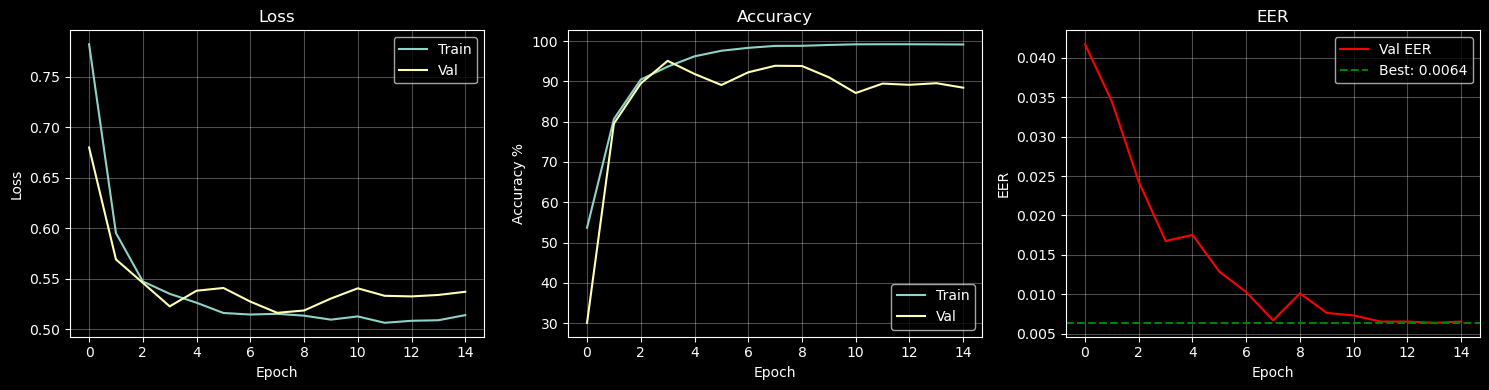

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(trainer.train_losses, label='Train')
axes[0].plot(trainer.val_losses, label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(trainer.train_accs, label='Train')
axes[1].plot(trainer.val_accs, label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy %')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(trainer.val_eers, color='red', label='Val EER')
axes[2].axhline(y=trainer.best_eer, color='green', linestyle='--', label=f'Best: {trainer.best_eer:.4f}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('EER')
axes[2].set_title('EER')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig_dir = Path(config['paths']['experiments_root']) / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / 'cnn_training_curves.png', dpi=150)
plt.show()
